# Modelo ConvTransformer para detección binaria y localización temporal usando `dx(t)`

Este cuaderno evalúa una arquitectura ConvTransformer aplicada a trayectorias sintéticas de difusión anómala con y sin punto de cambio, combinando detección binaria y localización temporal a partir de la serie de incrementos `dx(t)`.

## Enfoque del cuaderno

Este cuaderno evalúa una arquitectura ConvTransformer en la segunda fase experimental del proyecto, dedicada a trayectorias de difusión anómala con y sin punto de cambio. El análisis se centra en combinar extracción local mediante convoluciones 1D y modelado temporal mediante atención sobre la serie de incrementos `dx(t)`.

La tarea se formula con dos salidas: `has_cp` para la detección binaria de la presencia de cambio y `cp_dist` para la localización temporal del punto de cambio cuando la trayectoria contiene una transición.

## 1. Configuración experimental

Se definen los parámetros generales de ejecución, las rutas de entrada y salida, las semillas aleatorias y las opciones que controlan el tamaño del experimento. El modo rápido permite comprobar el flujo completo con un subconjunto equilibrado, mientras que el modo global utiliza todas las trayectorias disponibles.

Para una ejecución exploratoria se mantiene `FAST_RUN = True` y `GLOBAL_RUN = False`. Una vez verificada la carga de datos, el entrenamiento, el guardado del modelo y la evaluación, puede activarse la ejecución global mediante `FAST_RUN = False` y `GLOBAL_RUN = True`.

In [1]:

import json
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, losses, metrics, optimizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

FAST_RUN = False
GLOBAL_RUN = True
GLOBAL_SHORT_TEST = False
GLOBAL_SHORT_EPOCHS = 3

FAST_TRAIN_SIZE = 20_000
FAST_VAL_SIZE = 4_000
FAST_TEST_SIZE = 10_000

LENGTH = 100
DX_LENGTH = LENGTH - 1
MIN_SEGMENT_LENGTH = 20
VALID_DX_MIN = MIN_SEGMENT_LENGTH - 1
VALID_DX_MAX = LENGTH - MIN_SEGMENT_LENGTH - 1

MODEL_NAMES = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
MODEL_MAP = {i: name for i, name in enumerate(MODEL_NAMES)}
TRANSITIONS = [(m1, m2) for m1 in MODEL_NAMES for m2 in MODEL_NAMES if m1 != m2]
TRANSITION_ORDER = [f"{m1} → {m2}" for m1, m2 in TRANSITIONS]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_with_without_changepoint_dx"

OUTPUT_DIR = PROJECT_ROOT / "model_outputs" / (
    "convtransformer_softmax_fpr_fine_thresholds_fast_detection_localization_dx" if FAST_RUN else "convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx"
)
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
MAX_EPOCHS = GLOBAL_SHORT_EPOCHS if (GLOBAL_RUN and GLOBAL_SHORT_TEST) else (30 if FAST_RUN else 100)
LEARNING_RATE = 1e-3
LOSS_WEIGHTS = [2.0, 1.0]
THRESHOLDS = np.array([0.30, 0.32, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.42, 0.45], dtype=float)
MONITOR_METRIC = "val_selection_score"

DATA_FILES = {
    "train": DATA_DIR / f"train_L{LENGTH}_dim1_with_without_dx.h5",
    "val": DATA_DIR / f"val_L{LENGTH}_dim1_with_without_dx.h5",
    "test": DATA_DIR / f"test_L{LENGTH}_dim1_with_without_dx.h5",
}

if FAST_RUN == GLOBAL_RUN:
    raise ValueError("Choose exactly one mode: FAST_RUN=True or GLOBAL_RUN=True.")

pd.DataFrame({
    "item": ["FAST_RUN", "GLOBAL_RUN", "GLOBAL_SHORT_TEST", "OUTPUT_DIR", "BATCH_SIZE", "MAX_EPOCHS", "LOSS_WEIGHTS"],
    "value": [FAST_RUN, GLOBAL_RUN, GLOBAL_SHORT_TEST, str(OUTPUT_DIR), BATCH_SIZE, MAX_EPOCHS, str(LOSS_WEIGHTS)],
})


,item,value
0,FAST_RUN,False
1,GLOBAL_RUN,True
2,GLOBAL_SHORT_TEST,False
3,OUTPUT_DIR,C:\Users\chair\Downloads\changepoint_new_phase...
4,BATCH_SIZE,256
5,MAX_EPOCHS,100
6,LOSS_WEIGHTS,"[2.0, 1.0]"


## 2. Carga de datos experimentales

Se leen las particiones HDF5 generadas en el cuaderno de construcción del conjunto sintético. En esta fase, la entrada utilizada por el modelo es `dx(t)`, por lo que la posición absoluta `x(t)` no se incorpora directamente al entrenamiento.

La comprobación inicial se limita a verificar la disponibilidad y coherencia básica de las variables necesarias, ya que la validación estructural del conjunto de datos se documenta en el cuaderno correspondiente.


In [2]:

def decode_model(value):
    if isinstance(value, bytes):
        text = value.decode("utf-8")
        return text
    if isinstance(value, str):
        return value
    return MODEL_MAP[int(value)]


def normalize_dx(dx):
    mean = dx.mean(axis=1, keepdims=True)
    std = dx.std(axis=1, keepdims=True)
    return (dx - mean) / np.maximum(std, 1e-6)


def load_split(split_name):
    file_path = DATA_FILES[split_name]
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    with h5py.File(file_path, "r") as file:
        dx = file["dx"][:].astype("float32")
        has_cp = file["has_changepoint"][:].astype("float32")
        cp = file["cp"][:].astype("int16")
        cp_dx = file["cp_dx"][:].astype("int16") if "cp_dx" in file else (cp - 1).astype("int16")
        model1 = file["model1"][:]
        model2 = file["model2"][:]

    if dx.ndim == 2:
        dx = dx[:, :, None]

    dx = normalize_dx(dx).astype("float32")
    cp_class = np.where(has_cp == 1, cp_dx, 0).astype("int32")

    metadata = pd.DataFrame({
        "split": split_name,
        "has_changepoint": has_cp.astype(int),
        "cp": cp,
        "cp_dx": cp_dx,
        "cp_class": cp_class,
        "model1": [decode_model(value) for value in model1],
        "model2": [decode_model(value) for value in model2],
    })

    metadata["transition"] = np.where(
        metadata["has_changepoint"] == 1,
        metadata["model1"] + " → " + metadata["model2"],
        metadata["model1"] + " (no changepoint)",
    )

    return dx, has_cp.reshape(-1, 1).astype("float32"), cp_class.astype("int32"), metadata


x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full = load_split("train")
x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full = load_split("val")
x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full = load_split("test")

pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_examples": [len(x_train_full), len(x_val_full), len(x_test_full)],
    "dx_shape": [x_train_full.shape[1:], x_val_full.shape[1:], x_test_full.shape[1:]],
})


,split,n_examples,dx_shape
0,train,200000,"(99, 1)"
1,validation,20000,"(99, 1)"
2,test,200000,"(99, 1)"


## 3. Selección del régimen de ejecución

El modo rápido selecciona un subconjunto equilibrado de trayectorias con y sin punto de cambio para validar la ejecución completa del cuaderno. El modo global emplea cada partición en su totalidad y se reserva para la evaluación experimental final.

Esta separación permite distinguir entre una comprobación funcional del procedimiento y el entrenamiento completo destinado a producir resultados comparables entre arquitecturas.

In [3]:

def balanced_subset(x, y_has, y_cp_class, metadata, n_total, seed):
    rng = np.random.default_rng(seed)
    n_with = n_total // 2
    n_without = n_total - n_with

    with_meta = metadata[metadata["has_changepoint"] == 1]
    without_meta = metadata[metadata["has_changepoint"] == 0]

    selected = []

    per_transition = n_with // len(TRANSITION_ORDER)
    extra_transition = n_with % len(TRANSITION_ORDER)

    for i, transition in enumerate(TRANSITION_ORDER):
        group = with_meta[with_meta["transition"] == transition].index.to_numpy()
        k = per_transition + (1 if i < extra_transition else 0)
        selected.extend(rng.choice(group, size=min(k, len(group)), replace=False))

    per_model = n_without // len(MODEL_NAMES)
    extra_model = n_without % len(MODEL_NAMES)

    for i, model_name in enumerate(MODEL_NAMES):
        group = without_meta[without_meta["model1"] == model_name].index.to_numpy()
        k = per_model + (1 if i < extra_model else 0)
        selected.extend(rng.choice(group, size=min(k, len(group)), replace=False))

    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)

    return (
        x[selected],
        y_has[selected],
        y_cp_class[selected],
        metadata.loc[selected].reset_index(drop=True),
    )


if FAST_RUN:
    x_train, y_has_train, y_cp_train, train_metadata = balanced_subset(
        x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full, FAST_TRAIN_SIZE, RANDOM_SEED
    )
    x_val, y_has_val, y_cp_val, val_metadata = balanced_subset(
        x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full, FAST_VAL_SIZE, RANDOM_SEED + 1
    )
    x_test, y_has_test, y_cp_test, test_metadata = balanced_subset(
        x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full, FAST_TEST_SIZE, RANDOM_SEED + 2
    )
else:
    x_train, y_has_train, y_cp_train, train_metadata = x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full
    x_val, y_has_val, y_cp_val, val_metadata = x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full
    x_test, y_has_test, y_cp_test, test_metadata = x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full

summary_rows = []
for name, x, y_has, metadata in [
    ("train", x_train, y_has_train, train_metadata),
    ("validation", x_val, y_has_val, val_metadata),
    ("test", x_test, y_has_test, test_metadata),
]:
    counts = metadata["has_changepoint"].value_counts().sort_index()
    summary_rows.append({
        "split": name,
        "n_examples": len(x),
        "dx_shape": x.shape[1:],
        "no_changepoint": int(counts.get(0, 0)),
        "changepoint": int(counts.get(1, 0)),
        "n_available_transitions": int(metadata[metadata["has_changepoint"] == 1]["transition"].nunique()),
    })

pd.DataFrame(summary_rows)


,split,n_examples,dx_shape,no_changepoint,changepoint,n_available_transitions
0,train,200000,"(99, 1)",100000,100000,20
1,validation,20000,"(99, 1)",10000,10000,20
2,test,200000,"(99, 1)",100000,100000,20


## 3.1 Aleatorización reproducible del conjunto de entrenamiento

El conjunto de entrenamiento puede estar organizado por bloques según la clase o el modelo de difusión. Si los lotes sucesivos son demasiado homogéneos, el proceso de optimización puede verse sesgado aunque el equilibrio global sea correcto.

Para evitarlo, se aplica una permutación aleatoria reproducible únicamente sobre el conjunto de entrenamiento antes de construir el objeto `tf.data.Dataset`. Las particiones de validación y test se mantienen sin mezclar para conservar una evaluación estable y comparable.

In [4]:

rng = np.random.default_rng(RANDOM_SEED)
train_permutation = rng.permutation(len(x_train))

x_train = x_train[train_permutation]
y_has_train = y_has_train[train_permutation]
y_cp_train = y_cp_train[train_permutation]
train_metadata = train_metadata.iloc[train_permutation].reset_index(drop=True)

print("Global train label distribution after shuffle:")
print(pd.Series(y_has_train.reshape(-1)).value_counts())

print("First 20k train labels after shuffle:")
print(pd.Series(y_has_train[:20000].reshape(-1)).value_counts())

print("Middle 20k train labels after shuffle:")
mid = len(y_has_train) // 2
print(pd.Series(y_has_train[mid:mid+20000].reshape(-1)).value_counts())

print("Last 20k train labels after shuffle:")
print(pd.Series(y_has_train[-20000:].reshape(-1)).value_counts())


Global train label distribution after shuffle:
0.0    100000
1.0    100000
Name: count, dtype: int64
First 20k train labels after shuffle:
0.0    10105
1.0     9895
Name: count, dtype: int64
Middle 20k train labels after shuffle:
0.0    10014
1.0     9986
Name: count, dtype: int64
Last 20k train labels after shuffle:
1.0    10017
0.0     9983
Name: count, dtype: int64


## 4. Definición de etiquetas y ponderación de pérdidas

La salida `has_cp` se define para todas las trayectorias y permite entrenar la detección binaria. La salida `cp_dist` solo tiene significado físico cuando existe un punto de cambio real, por lo que la pérdida de localización se pondera con valor cero en las trayectorias sin punto de cambio.

Esta formulación evita imponer una posición artificial a trayectorias homogéneas y separa explícitamente el aprendizaje de la presencia del cambio de la estimación de su ubicación temporal.

In [5]:

def make_sample_weights(y_has):
    y_flat = y_has.reshape(-1).astype("float32")
    return (
        np.ones_like(y_flat, dtype="float32"),
        y_flat.astype("float32"),
    )


def make_dataset(x, y_has, y_cp_class, training=False):
    y = (
        y_has.astype("float32"),
        y_cp_class.astype("int32"),
    )
    sample_weight = make_sample_weights(y_has)
    dataset = tf.data.Dataset.from_tensor_slices((x, y, sample_weight))
    if training:
        dataset = dataset.shuffle(min(10_000, len(x)), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(x_train, y_has_train, y_cp_train, training=True)
val_ds = make_dataset(x_val, y_has_val, y_cp_val, training=False)
test_ds = make_dataset(x_test, y_has_test, y_cp_test, training=False)

print("Datasets ready.")
print("Output order: [has_cp, cp_dist]")


Datasets ready.
Output order: [has_cp, cp_dist]


## 5. Estrategia de ponderación y selección fina de umbrales

La detección binaria requiere equilibrar dos riesgos: clasificar como cambiantes trayectorias homogéneas y no detectar transiciones reales. Para abordar este compromiso, el entrenamiento incorpora una ponderación específica de la clase sin punto de cambio y una búsqueda de umbral más detallada en la zona de decisión relevante.

Los valores definidos en el código, como `negative_weight`, `LOSS_WEIGHTS` y la malla de umbrales, forman parte de la configuración experimental. Su función es ajustar el equilibrio entre la tasa de falsos positivos y la sensibilidad de detección, manteniendo la salida `cp_dist` como representación temporal del punto de cambio.

## 6. Arquitectura ConvTransformer

El modelo incorpora un bloque convolucional 1D antes de los módulos de atención. Las convoluciones extraen patrones locales en `dx(t)`, mientras que la atención multi-cabeza integra relaciones temporales de mayor alcance.

La salida `has_cp` estima la probabilidad de presencia de punto de cambio mediante una activación sigmoide. La salida `cp_dist` produce una distribución `softmax` sobre las posiciones temporales válidas y se utiliza para la localización temporal.

In [6]:

@tf.keras.utils.register_keras_serializable(package="Changepoint")
class ValidPositionMask(layers.Layer):
    def __init__(self, sequence_length, valid_min, valid_max, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.valid_min = int(valid_min)
        self.valid_max = int(valid_max)

    def call(self, logits):
        positions = tf.range(self.sequence_length)
        valid = tf.logical_and(positions >= self.valid_min, positions <= self.valid_max)
        valid = tf.cast(valid, tf.float32)
        mask = (1.0 - valid) * (-1e9)
        return logits + mask[tf.newaxis, :]

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "valid_min": self.valid_min,
            "valid_max": self.valid_max,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="Changepoint")
class LastStep(layers.Layer):
    def call(self, inputs):
        return inputs[:, -1, :]


@tf.keras.utils.register_keras_serializable(package="Changepoint")
class SqueezeLastAxis(layers.Layer):
    def call(self, inputs):
        return tf.squeeze(inputs, axis=-1)


@tf.keras.utils.register_keras_serializable(package="Changepoint")
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.d_model = int(d_model)
        self.position_embedding = layers.Embedding(
            input_dim=self.sequence_length,
            output_dim=self.d_model,
            name="position_embedding_table",
        )

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        embedded_positions = self.position_embedding(positions)
        return inputs + embedded_positions[tf.newaxis, :, :]

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "d_model": self.d_model,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="Changepoint")
def sparse_ce_localization(y_true, y_pred):
    y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    n_positions = tf.shape(y_pred)[1]
    y_true = tf.clip_by_value(y_true, 0, n_positions - 1)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    batch_size = tf.shape(y_pred)[0]
    gather_indices = tf.stack([tf.range(batch_size, dtype=tf.int32), y_true], axis=1)
    true_prob = tf.gather_nd(y_pred, gather_indices)
    return -tf.math.log(true_prob)


@tf.keras.utils.register_keras_serializable(package="Changepoint")
def weighted_binary_crossentropy_no_cp(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    positive_weight = tf.constant(1.0, dtype=tf.float32)
    negative_weight = tf.constant(1.8, dtype=tf.float32)

    positive_loss = -positive_weight * y_true * tf.math.log(y_pred)
    negative_loss = -negative_weight * (1.0 - y_true) * tf.math.log(1.0 - y_pred)

    return tf.reduce_mean(positive_loss + negative_loss)


def conv_stem_block(x, d_model, dropout_rate):
    """Local feature extractor before the attention blocks."""
    x = layers.Conv1D(
        filters=d_model // 2,
        kernel_size=5,
        padding="same",
        name="conv_stem_1",
    )(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="conv_stem_norm_1")(x)
    x = layers.Activation("gelu", name="conv_stem_gelu_1")(x)
    x = layers.Dropout(dropout_rate, name="conv_stem_dropout_1")(x)

    x = layers.Conv1D(
        filters=d_model,
        kernel_size=3,
        padding="same",
        name="conv_stem_2",
    )(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="conv_stem_norm_2")(x)
    x = layers.Activation("gelu", name="conv_stem_gelu_2")(x)
    x = layers.Dropout(dropout_rate, name="conv_stem_dropout_2")(x)
    return x


def conv_residual_block(x, d_model, kernel_size, dropout_rate, block_id, dilation_rate=1):
    """Residual Conv1D block that preserves the temporal length."""
    residual = x

    y = layers.Conv1D(
        filters=d_model,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        name=f"conv_residual_{block_id}_conv_1",
    )(x)
    y = layers.LayerNormalization(epsilon=1e-6, name=f"conv_residual_{block_id}_norm_1")(y)
    y = layers.Activation("gelu", name=f"conv_residual_{block_id}_gelu_1")(y)
    y = layers.Dropout(dropout_rate, name=f"conv_residual_{block_id}_dropout_1")(y)

    y = layers.Conv1D(
        filters=d_model,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        name=f"conv_residual_{block_id}_conv_2",
    )(y)
    y = layers.Dropout(dropout_rate, name=f"conv_residual_{block_id}_dropout_2")(y)

    x = layers.Add(name=f"conv_residual_{block_id}_add")([residual, y])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"conv_residual_{block_id}_norm_2")(x)
    return x


def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout_rate, block_id):
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate,
        name=f"transformer_{block_id}_mha",
    )(x, x)
    attention_output = layers.Dropout(dropout_rate, name=f"transformer_{block_id}_attn_dropout")(attention_output)
    x = layers.Add(name=f"transformer_{block_id}_attn_add")([x, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_attn_norm")(x)

    ffn = layers.Dense(ff_dim, activation="gelu", name=f"transformer_{block_id}_ffn_dense_1")(x)
    ffn = layers.Dropout(dropout_rate, name=f"transformer_{block_id}_ffn_dropout_1")(ffn)
    ffn = layers.Dense(d_model, name=f"transformer_{block_id}_ffn_dense_2")(ffn)
    ffn = layers.Dropout(dropout_rate, name=f"transformer_{block_id}_ffn_dropout_2")(ffn)
    x = layers.Add(name=f"transformer_{block_id}_ffn_add")([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_ffn_norm")(x)
    return x


def build_convtransformer_detection_localization_model(
    input_shape=(DX_LENGTH, 1),
    d_model=96,
    num_heads=4,
    ff_dim=192,
    num_transformer_blocks=3,
    num_conv_blocks=2,
    conv_kernel_size=5,
    dropout_rate=0.15,
):
    inputs = layers.Input(shape=input_shape, name="dx_input")

    # ConvTransformer change: local Conv1D feature extraction before attention.
    x = conv_stem_block(inputs, d_model=d_model, dropout_rate=dropout_rate)

    for conv_id in range(1, num_conv_blocks + 1):
        dilation_rate = 1 if conv_id == 1 else 2
        x = conv_residual_block(
            x=x,
            d_model=d_model,
            kernel_size=conv_kernel_size,
            dropout_rate=dropout_rate,
            block_id=conv_id,
            dilation_rate=dilation_rate,
        )

    x = PositionalEmbedding(input_shape[0], d_model, name="positional_embedding")(x)
    x = layers.Dropout(dropout_rate, name="embedding_dropout")(x)

    for block_id in range(1, num_transformer_blocks + 1):
        x = transformer_encoder_block(
            x=x,
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            block_id=block_id,
        )

    avg_pool = layers.GlobalAveragePooling1D(name="average_pooling")(x)
    max_pool = layers.GlobalMaxPooling1D(name="max_pooling")(x)
    last_state = LastStep(name="last_state")(x)

    shared = layers.Concatenate(name="shared_features")([avg_pool, max_pool, last_state])
    shared = layers.Dense(128, activation="gelu", name="shared_dense_1")(shared)
    shared = layers.Dropout(0.25, name="shared_dropout_1")(shared)
    shared = layers.Dense(64, activation="gelu", name="shared_dense_2")(shared)

    det = layers.Dense(64, activation="gelu", name="detection_dense_1")(shared)
    det = layers.Dropout(0.20, name="detection_dropout")(det)
    has_cp = layers.Dense(1, activation="sigmoid", name="has_cp")(det)

    loc = layers.Dense(96, activation="gelu", name="localization_dense_1")(x)
    loc = layers.Dropout(0.15, name="localization_dropout")(loc)
    loc = layers.Dense(48, activation="gelu", name="localization_dense_2")(loc)
    logits = layers.Dense(1, name="localization_logits_dense")(loc)
    logits = SqueezeLastAxis(name="localization_logits")(logits)
    logits = ValidPositionMask(DX_LENGTH, VALID_DX_MIN, VALID_DX_MAX, name="valid_position_mask")(logits)
    cp_dist = layers.Activation("softmax", name="cp_dist")(logits)

    return models.Model(inputs=inputs, outputs=[has_cp, cp_dist], name="convtransformer_detection_localization_dx")


model = build_convtransformer_detection_localization_model(input_shape=(DX_LENGTH, 1))

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=[
        weighted_binary_crossentropy_no_cp,
        sparse_ce_localization,
    ],
    loss_weights=LOSS_WEIGHTS,
    metrics=[
        [
            metrics.BinaryAccuracy(name="accuracy"),
            metrics.Precision(name="precision"),
            metrics.Recall(name="recall"),
        ],
        [
            metrics.SparseCategoricalAccuracy(name="sparse_accuracy"),
        ],
    ],
)

model.summary()


Model: "convtransformer_detection_localization_dx"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dx_input (InputLayer)         │ (None, 99, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_1 (Conv1D)          │ (None, 99, 48)            │             288 │ dx_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_norm_1              │ (None, 99, 48)            │              96 │ conv_stem_1[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_gelu_1 (Activation) │ (None, 99, 48)            │               0 │ conv_stem_norm_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_dropout_1 (Dropout) │ (None, 99, 48)            │               0 │ conv_stem_gelu_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_2 (Conv1D)          │ (None, 99, 96)            │          13,920 │ conv_stem_dropout_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_norm_2              │ (None, 99, 96)            │             192 │ conv_stem_2[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_gelu_2 (Activation) │ (None, 99, 96)            │               0 │ conv_stem_norm_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_dropout_2 (Dropout) │ (None, 99, 96)            │               0 │ conv_stem_gelu_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_residual_1_conv_1        │ (None, 99, 96)            │          46,176 │ conv_stem_dropout_2[0][0]  │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_residual_1_norm_1        │ (None, 99, 96)            │             192 │ conv_residual_1_conv_1[0]… │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_residual_1_gelu_1        │ (None, 99, 96)            │               0 │ conv_residual_1_norm_1[0]… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_residual_1_dropout_1     │ (None, 99, 96)            │               0 │ conv_residual_1_gelu_1[0]… │
│ (Dropout)                     │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_residual_1_conv_2        │ (None, 99, 96)            │          46,176 │ conv_residual_1_dropout_1… │
│ (Conv1D)                      │                           │               

 Total params: 497,314 (1.90 MB)

 Trainable params: 497,314 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Métricas de validación y selección del umbral

Durante el entrenamiento se calcula un criterio de validación que combina calidad de detección, control de falsos positivos y precisión de localización temporal. El umbral final se selecciona a partir del conjunto de validación, no como un valor fijo independiente de los datos.

Esta selección permite ajustar la sensibilidad del modelo ante trayectorias con punto de cambio y su robustez frente a trayectorias homogéneas.


In [7]:

def unpack_predictions(predictions):
    if isinstance(predictions, (list, tuple)):
        return predictions[0], predictions[1]
    return predictions["has_cp"], predictions["cp_dist"]


def detection_metrics(y_true, probabilities, threshold):
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    probabilities = np.asarray(probabilities).reshape(-1)
    y_pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_positive_rate": float(fp / (fp + tn + 1e-8)),
        "false_negative_rate": float(fn / (fn + tp + 1e-8)),
        "jaccard_coefficient": float(tp / (tp + fp + fn + 1e-8)),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


def soft_positions(cp_dist):
    positions = np.arange(cp_dist.shape[1], dtype=np.float32)
    return np.sum(cp_dist * positions.reshape(1, -1), axis=1) + 1.0


def localization_metrics(metadata, probabilities, cp_dist, threshold):
    y_true_has = metadata["has_changepoint"].to_numpy(dtype=int)
    y_pred_has = (np.asarray(probabilities).reshape(-1) >= threshold).astype(int)
    pred_cp = soft_positions(cp_dist)

    mask_all = y_true_has == 1
    mask_tp = (y_true_has == 1) & (y_pred_has == 1)

    def compute(mask, prefix):
        if int(mask.sum()) == 0:
            return {f"{prefix}_n": 0, f"{prefix}_mae": np.nan, f"{prefix}_rmse": np.nan}
        true_cp = metadata.loc[mask, "cp"].to_numpy(dtype=np.float32)
        return {
            f"{prefix}_n": int(mask.sum()),
            f"{prefix}_mae": float(mean_absolute_error(true_cp, pred_cp[mask])),
            f"{prefix}_rmse": float(np.sqrt(mean_squared_error(true_cp, pred_cp[mask]))),
        }

    values = {}
    values.update(compute(mask_all, "all_changepoint"))
    values.update(compute(mask_tp, "true_positive"))
    return values


def threshold_table(y_true, probabilities, cp_dist, metadata, thresholds=THRESHOLDS):
    rows = []
    for threshold in thresholds:
        row = detection_metrics(y_true, probabilities, threshold)
        row.update(localization_metrics(metadata, probabilities, cp_dist, threshold))
        rows.append(row)
    return pd.DataFrame(rows)


def choose_threshold(table):
    candidates = table[
        (table["false_positive_rate"] <= 0.35) &
        (table["recall"] >= 0.65)
    ].copy()

    if candidates.empty:
        candidates = table[
            (table["false_positive_rate"] <= 0.45) &
            (table["recall"] >= 0.60)
        ].copy()

    if candidates.empty:
        candidates = table.copy()

    candidates = candidates.sort_values(
        ["f1_score", "false_positive_rate", "precision"],
        ascending=[False, True, False],
    )

    return candidates.iloc[0].to_dict()


class ValidationMetricsCallback(callbacks.Callback):
    def __init__(self, x_val, y_has_val, val_metadata, batch_size=2048):
        super().__init__()
        self.x_val = x_val
        self.y_has_val = y_has_val.reshape(-1).astype(int)
        self.val_metadata = val_metadata.reset_index(drop=True)
        self.batch_size = batch_size
        self.records = []
        self.threshold_records = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        has_prob, cp_dist = unpack_predictions(self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0))
        has_prob = has_prob.reshape(-1)
        cp_dist = np.asarray(cp_dist)

        table = threshold_table(self.y_has_val, has_prob, cp_dist, self.val_metadata, THRESHOLDS)
        best = choose_threshold(table)
        score = (
            best["all_changepoint_mae"]
            + 20.0 * (1.0 - best["f1_score"])
            + 18.0 * best["false_positive_rate"]
            + 10.0 * max(0.0, 0.70 - best["recall"])
        )

        record = {
            "epoch": epoch + 1,
            "val_best_threshold": float(best["threshold"]),
            "val_detection_accuracy": float(best["accuracy"]),
            "val_detection_precision": float(best["precision"]),
            "val_detection_recall": float(best["recall"]),
            "val_detection_f1": float(best["f1_score"]),
            "val_false_positive_rate": float(best["false_positive_rate"]),
            "val_false_negative_rate": float(best["false_negative_rate"]),
            "val_jaccard_coefficient": float(best["jaccard_coefficient"]),
            "val_localization_mae_all_cp": float(best["all_changepoint_mae"]),
            "val_localization_rmse_all_cp": float(best["all_changepoint_rmse"]),
            "val_localization_mae_true_positive": float(best["true_positive_mae"]),
            "val_localization_rmse_true_positive": float(best["true_positive_rmse"]),
            "val_selection_score": float(score),
        }

        self.records.append(record)
        table["epoch"] = epoch + 1
        self.threshold_records.append(table)
        logs.update({k: v for k, v in record.items() if k != "epoch"})

        print(
            f"\nval_threshold={record['val_best_threshold']:.2f} | "
            f"F1={record['val_detection_f1']:.4f} | "
            f"recall={record['val_detection_recall']:.4f} | "
            f"FPR={record['val_false_positive_rate']:.4f} | "
            f"RMSE_TP={record['val_localization_rmse_true_positive']:.2f}"
        )


val_metrics_callback = ValidationMetricsCallback(x_val, y_has_val, val_metadata)


## 8. Estrategia de entrenamiento y almacenamiento local

El entrenamiento utiliza mecanismos de seguimiento para registrar métricas, guardar el mejor modelo, ajustar la tasa de aprendizaje y detener la optimización cuando la validación deja de mejorar. Los artefactos generados durante este proceso se guardan localmente y no deben incorporarse al repositorio.

La opción `GLOBAL_SHORT_TEST` permite validar la ejecución global de forma abreviada antes de lanzar la configuración completa.

In [8]:

checkpoint_path = OUTPUT_DIR / "best_convtransformer_detection_localization_dx.keras"
training_log_path = OUTPUT_DIR / "training_log_convtransformer_detection_localization_dx.csv"

training_callbacks = [
    val_metrics_callback,
    callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor=MONITOR_METRIC,
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor=MONITOR_METRIC,
        patience=8 if FAST_RUN else 15,
        mode="min",
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor=MONITOR_METRIC,
        factor=0.5,
        patience=4 if FAST_RUN else 6,
        mode="min",
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.CSVLogger(training_log_path),
]

print("Active mode:", "FAST_RUN" if FAST_RUN else "GLOBAL_RUN")
print("Global short test:", GLOBAL_SHORT_TEST)
print("Output directory:", OUTPUT_DIR)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=training_callbacks,
    verbose=1,
)


Active mode: GLOBAL_RUN
Global short test: False
Output directory: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx
Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cp_dist_loss: 2.0064 - cp_dist_sparse_accuracy: 0.0196 - has_cp_accuracy: 0.5152 - has_cp_loss: 0.9076 - has_cp_precision: 0.6442 - has_cp_recall: 0.0476 - loss: 3.8216   
val_threshold=0.30 | F1=0.6721 | recall=0.6027 | FPR=0.1909 | RMSE_TP=14.38

Epoch 1: val_selection_score improved from None to 23.83309, saving model to C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\best_convtransformer_detection_localization_dx.keras

Epoch 1: finished saving model to C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\best_convtransformer_detection_lo

## 9. Evaluación posterior al entrenamiento

Después del entrenamiento se recarga el mejor modelo según el desempeño de validación. La selección del umbral se realiza con la partición de validación y la evaluación final se calcula sobre el conjunto de test.

Este procedimiento separa la optimización, la selección del criterio de decisión y la estimación final del rendimiento.

In [9]:

history_frame = pd.DataFrame(history.history)
validation_metrics_frame = pd.DataFrame(val_metrics_callback.records)
threshold_history_frame = pd.concat(val_metrics_callback.threshold_records, ignore_index=True)

history_frame.to_csv(OUTPUT_DIR / "history_convtransformer_detection_localization_dx.csv", index=False)
validation_metrics_frame.to_csv(OUTPUT_DIR / "validation_metrics_convtransformer_detection_localization_dx.csv", index=False)
threshold_history_frame.to_csv(OUTPUT_DIR / "threshold_history_convtransformer_detection_localization_dx.csv", index=False)

best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={
        "ValidPositionMask": ValidPositionMask,
        "LastStep": LastStep,
        "SqueezeLastAxis": SqueezeLastAxis,
        "PositionalEmbedding": PositionalEmbedding,
        "sparse_ce_localization": sparse_ce_localization,
        "weighted_binary_crossentropy_no_cp": weighted_binary_crossentropy_no_cp,
    },
    compile=False,
    safe_mode=False,
)

def predict_outputs(model_to_use, x):
    has_prob, cp_dist = unpack_predictions(model_to_use.predict(x, batch_size=BATCH_SIZE, verbose=1))
    return np.asarray(has_prob).reshape(-1), np.asarray(cp_dist)


val_has_prob, val_cp_dist = predict_outputs(best_model, x_val)
test_has_prob, test_cp_dist = predict_outputs(best_model, x_test)

validation_threshold_table = threshold_table(y_has_val, val_has_prob, val_cp_dist, val_metadata, THRESHOLDS)
test_threshold_table = threshold_table(y_has_test, test_has_prob, test_cp_dist, test_metadata, THRESHOLDS)

selected_threshold = float(choose_threshold(validation_threshold_table)["threshold"])
validation_threshold_table["selected"] = validation_threshold_table["threshold"] == selected_threshold
test_threshold_table["selected"] = test_threshold_table["threshold"] == selected_threshold

validation_threshold_table.to_csv(OUTPUT_DIR / "threshold_comparison_validation.csv", index=False)
test_threshold_table.to_csv(OUTPUT_DIR / "threshold_comparison_test.csv", index=False)

print("Threshold Comparison for Changepoint Detection — Validation")
display(validation_threshold_table)

print("Threshold Comparison for Changepoint Detection — Test")
display(test_threshold_table)

print("Selected threshold:", selected_threshold)


C:\Users\chair\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 653ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 503s 644ms/step
Threshold Comparison for Changepoint Detection — Validation


,threshold,accuracy,precision,recall,f1_score,false_positive_rate,false_negative_rate,jaccard_coefficient,true_negatives,false_positives,false_negatives,true_positives,all_changepoint_n,all_changepoint_mae,all_changepoint_rmse,true_positive_n,true_positive_mae,true_positive_rmse,selected
0,0.30,0.80395,0.819846,0.7791,0.798954,0.1712,0.2209,0.665215,8288,1712,2209,7791,10000,7.596154,11.675595,7791,5.833695,9.731332,True
1,0.32,0.80425,0.834745,0.7587,0.794908,0.1502,0.2413,0.659624,8498,1502,2413,7587,10000,7.596154,11.675595,7587,5.639311,9.497078,False
2,0.34,0.80185,0.845011,0.7393,0.788629,0.1356,0.2607,0.651021,8644,1356,2607,7393,10000,7.596154,11.675595,7393,5.434033,9.247817,False
3,0.35,0.80055,0.849924,0.7300,0.785411,0.1289,0.2700,0.646647,8711,1289,2700,7300,10000,7.596154,11.675595,7300,5.341261,9.139559,False
4,0.36,0.79980,0.855213,0.7218,0.782863,0.1222,0.2782,0.643201,8778,1222,2782,7218,10000,7.596154,11.675595,7218,5.255581,9.031669,False
5,0.37,0.79890,0.860294,0.7137,0.780171,0.1159,0.2863,0.639573,8841,1159,2863,7137,10000,7.596154,11.675595,7137,5.170453,8.929461,False
6,0.38,0.79800,0.864481,0.7068,0.777729,0.1108,0.2932,0.636298,8892,1108,2932,7068,10000,7.596154,11.675595,7068,5.105521,8.856033,False
7,0.39,0.79680,0.869522,0.6984,0.774623,0.1048,0.3016,0.632151,8952,1048,3016,6984,10000,7.596154,11.675595,6984,5.003664,8.728577,False
8,0.40,0.79655,0.876859,0.6900,0.772287,0.0969,0.3100,0.629045,9031,969,3100,6900,10000,7.596154,11.675595,6900,4.927407,8.632831,False
9,0.42,0.79370,0.888492,0.6717,0.765034,0.0843,0.3283,0.619478,9157,843,3283,6717,10000,7.596154,11.675595,6717,4.755197,8.427689,False


Threshold Comparison for Changepoint Detection — Test


,threshold,accuracy,precision,recall,f1_score,false_positive_rate,false_negative_rate,jaccard_coefficient,true_negatives,false_positives,false_negatives,true_positives,all_changepoint_n,all_changepoint_mae,all_changepoint_rmse,true_positive_n,true_positive_mae,true_positive_rmse,selected
0,0.30,0.803675,0.818374,0.78059,0.799036,0.17324,0.21941,0.665328,82676,17324,21941,78059,100000,7.536969,11.570613,78059,5.779737,9.621539,True
1,0.32,0.804250,0.833922,0.75982,0.795148,0.15132,0.24018,0.659956,84868,15132,24018,75982,100000,7.536969,11.570613,75982,5.569788,9.367738,False
2,0.34,0.803400,0.845857,0.74202,0.790544,0.13522,0.25798,0.653635,86478,13522,25798,74202,100000,7.536969,11.570613,74202,5.400154,9.159787,False
3,0.35,0.803405,0.852121,0.73423,0.788795,0.12742,0.26577,0.651248,87258,12742,26577,73423,100000,7.536969,11.570613,73423,5.322380,9.067257,False
4,0.36,0.802650,0.857844,0.72553,0.786159,0.12023,0.27447,0.647662,87977,12023,27447,72553,100000,7.536969,11.570613,72553,5.239628,8.963705,False
5,0.37,0.801955,0.863595,0.71719,0.783613,0.11328,0.28281,0.644213,88672,11328,28281,71719,100000,7.536969,11.570613,71719,5.150911,8.849949,False
6,0.38,0.801265,0.869292,0.70916,0.781104,0.10663,0.29084,0.640828,89337,10663,29084,70916,100000,7.536969,11.570613,70916,5.076516,8.756150,False
7,0.39,0.800370,0.874722,0.70116,0.778383,0.10042,0.29884,0.637175,89958,10042,29884,70116,100000,7.536969,11.570613,70116,4.999300,8.652781,False
8,0.40,0.799485,0.880342,0.69319,0.775636,0.09422,0.30681,0.633501,90578,9422,30681,69319,100000,7.536969,11.570613,69319,4.913173,8.536920,False
9,0.42,0.797135,0.890500,0.67759,0.769591,0.08332,0.32241,0.625475,91668,8332,32241,67759,100000,7.536969,11.570613,67759,4.748953,8.325676,False


Selected threshold: 0.3


## 10. Métricas globales y matriz de confusión

Las métricas principales se calculan en el conjunto de test. La evaluación combina indicadores de detección binaria, métricas de localización temporal y una matriz de confusión para resumir la separación entre trayectorias con y sin punto de cambio.

El análisis conjunto permite valorar tanto la capacidad del modelo para reconocer cambios reales como su tendencia a generar falsas alarmas.

In [10]:

def save_current_figure(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=170, bbox_inches="tight")
    print("Saved figure:", path)


selected_test = test_threshold_table[test_threshold_table["threshold"] == selected_threshold].iloc[0].to_dict()
test_pred_has = (test_has_prob >= selected_threshold).astype(int)
test_true_has = y_has_test.reshape(-1).astype(int)
test_cm = confusion_matrix(test_true_has, test_pred_has, labels=[0, 1])

global_summary = pd.DataFrame([
    {"metric": "selected_threshold", "value": selected_threshold},
    {"metric": "accuracy", "value": selected_test["accuracy"]},
    {"metric": "precision", "value": selected_test["precision"]},
    {"metric": "recall", "value": selected_test["recall"]},
    {"metric": "f1_score", "value": selected_test["f1_score"]},
    {"metric": "false_positive_rate", "value": selected_test["false_positive_rate"]},
    {"metric": "false_negative_rate", "value": selected_test["false_negative_rate"]},
    {"metric": "jaccard_coefficient", "value": selected_test["jaccard_coefficient"]},
    {"metric": "mae_all_changepoint", "value": selected_test["all_changepoint_mae"]},
    {"metric": "rmse_all_changepoint", "value": selected_test["all_changepoint_rmse"]},
    {"metric": "mae_true_positive", "value": selected_test["true_positive_mae"]},
    {"metric": "rmse_true_positive", "value": selected_test["true_positive_rmse"]},
])

global_summary.to_csv(OUTPUT_DIR / "global_test_summary.csv", index=False)
global_summary


,metric,value
0,selected_threshold,0.300000
1,accuracy,0.803675
2,precision,0.818374
3,recall,0.780590
4,f1_score,0.799036
5,false_positive_rate,0.173240
6,false_negative_rate,0.219410
7,jaccard_coefficient,0.665328
8,mae_all_changepoint,7.536969
9,rmse_all_changepoint,11.570613


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\confusion_matrix_for_changepoint_detection.png


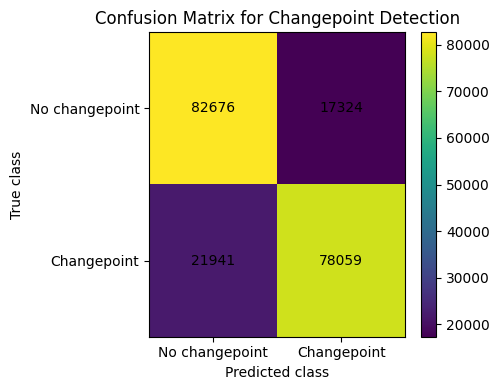

In [11]:

plt.figure(figsize=(5, 4))
plt.imshow(test_cm, aspect="auto")
plt.xticks([0, 1], ["No changepoint", "Changepoint"])
plt.yticks([0, 1], ["No changepoint", "Changepoint"])
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix for Changepoint Detection")
for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        plt.text(j, i, str(test_cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
save_current_figure("confusion_matrix_for_changepoint_detection.png")
plt.show()


## 11. Visualización del entrenamiento y del criterio de decisión

Las figuras de esta sección presentan la evolución de las pérdidas, las métricas de detección y la comparación entre los umbrales evaluados.

Estas visualizaciones permiten interpretar la estabilidad del entrenamiento y el efecto del umbral elegido sobre el equilibrio entre sensibilidad y control de falsos positivos.


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\training_and_validation_loss.png


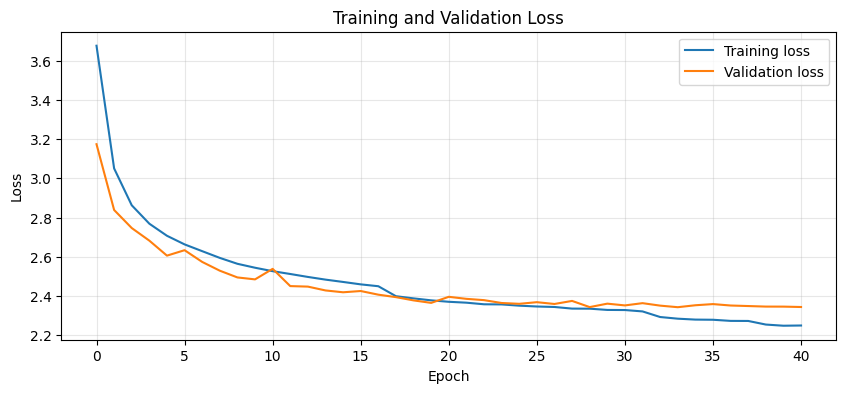

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\detection_metrics_across_epochs.png


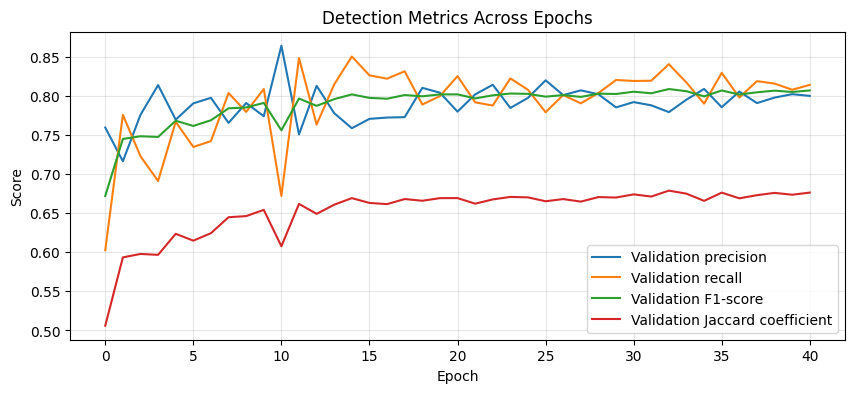

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\threshold_comparison_for_changepoint_detection.png


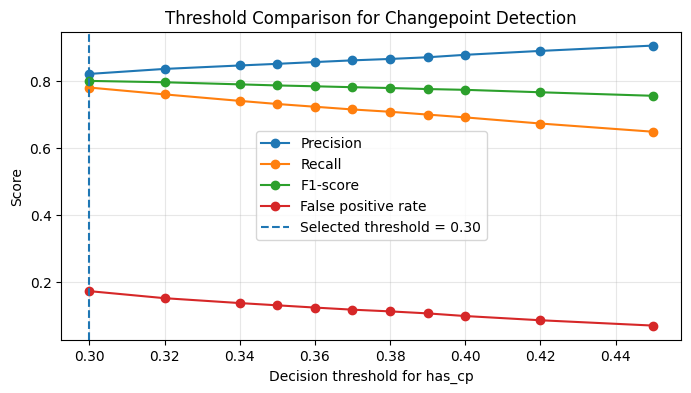

In [12]:

plt.figure(figsize=(10, 4))
plt.plot(history_frame["loss"], label="Training loss")
plt.plot(history_frame["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("training_and_validation_loss.png")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(validation_metrics_frame["val_detection_precision"], label="Validation precision")
plt.plot(validation_metrics_frame["val_detection_recall"], label="Validation recall")
plt.plot(validation_metrics_frame["val_detection_f1"], label="Validation F1-score")
plt.plot(validation_metrics_frame["val_jaccard_coefficient"], label="Validation Jaccard coefficient")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Detection Metrics Across Epochs")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("detection_metrics_across_epochs.png")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["precision"], marker="o", label="Precision")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["recall"], marker="o", label="Recall")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["f1_score"], marker="o", label="F1-score")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["false_positive_rate"], marker="o", label="False positive rate")
plt.axvline(selected_threshold, linestyle="--", label=f"Selected threshold = {selected_threshold:.2f}")
plt.xlabel("Decision threshold for has_cp")
plt.ylabel("Score")
plt.title("Threshold Comparison for Changepoint Detection")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("threshold_comparison_for_changepoint_detection.png")
plt.show()


## 12. Análisis por tipo de transición

El análisis por transición descompone el rendimiento según el par de modelos de difusión que define cada trayectoria con punto de cambio. Esta lectura permite identificar qué cambios de dinámica son más accesibles para la arquitectura ConvTransformer.

La información por transición complementa las métricas globales y ayuda a interpretar cómo el modelo responde a distintas combinaciones de difusión anómala dentro de la misma formulación de detección binaria y localización temporal.

In [13]:

test_pred_cp = soft_positions(test_cp_dist)

results_frame = test_metadata.copy()
results_frame["has_cp_prob"] = test_has_prob
results_frame["has_cp_pred"] = test_pred_has
results_frame["pred_cp"] = test_pred_cp
results_frame["abs_error"] = np.where(
    results_frame["has_changepoint"] == 1,
    np.abs(results_frame["pred_cp"] - results_frame["cp"]),
    np.nan,
)
results_frame["squared_error"] = np.where(
    results_frame["has_changepoint"] == 1,
    (results_frame["pred_cp"] - results_frame["cp"]) ** 2,
    np.nan,
)

transition_rows = []
with_cp = results_frame[results_frame["has_changepoint"] == 1].copy()

for transition in TRANSITION_ORDER:
    group = with_cp[with_cp["transition"] == transition].copy()
    if group.empty:
        continue
    tp_group = group[group["has_cp_pred"] == 1].copy()
    transition_rows.append({
        "transition": transition,
        "model1": group["model1"].iloc[0],
        "model2": group["model2"].iloc[0],
        "n_examples": int(len(group)),
        "n_true_positives": int((group["has_cp_pred"] == 1).sum()),
        "n_false_negatives": int((group["has_cp_pred"] == 0).sum()),
        "detection_recall": float((group["has_cp_pred"] == 1).mean()),
        "false_negative_rate": float((group["has_cp_pred"] == 0).mean()),
        "mae_all": float(group["abs_error"].mean()),
        "rmse_all": float(np.sqrt(group["squared_error"].mean())),
        "mae_true_positive": float(tp_group["abs_error"].mean()) if len(tp_group) else np.nan,
        "rmse_true_positive": float(np.sqrt(tp_group["squared_error"].mean())) if len(tp_group) else np.nan,
    })

transition_metrics = pd.DataFrame(transition_rows)
transition_metrics.to_csv(OUTPUT_DIR / "transition_level_metrics.csv", index=False)
transition_metrics.sort_values("rmse_true_positive").head(10)


,transition,model1,model2,n_examples,n_true_positives,n_false_negatives,detection_recall,false_negative_rate,mae_all,rmse_all,mae_true_positive,rmse_true_positive
6,CTRW → LW,CTRW,LW,5000,4864,136,0.9728,0.0272,2.900056,5.930214,2.636034,5.432540
13,LW → CTRW,LW,CTRW,5000,4857,143,0.9714,0.0286,3.011273,6.045670,2.748979,5.500955
2,ATTM → LW,ATTM,LW,5000,4528,472,0.9056,0.0944,4.939293,8.693556,4.069117,7.474002
12,LW → ATTM,LW,ATTM,5000,4548,452,0.9096,0.0904,5.278600,9.070479,4.386916,7.774135
15,LW → SBM,LW,SBM,5000,4356,644,0.8712,0.1288,5.800409,9.691602,4.532389,8.004930
14,LW → FBM,LW,FBM,5000,4200,800,0.8400,0.1600,6.229662,10.351095,4.641374,8.250490
10,FBM → LW,FBM,LW,5000,4184,816,0.8368,0.1632,6.289558,10.356236,4.823651,8.504706
7,CTRW → SBM,CTRW,SBM,5000,4489,511,0.8978,0.1022,6.127583,9.957211,5.141507,8.577706
19,SBM → LW,SBM,LW,5000,4333,667,0.8666,0.1334,6.239388,10.153011,5.033616,8.588371
9,FBM → CTRW,FBM,CTRW,5000,4286,714,0.8572,0.1428,6.417902,10.211293,5.198259,8.663970


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\detection_recall_by_transition.png


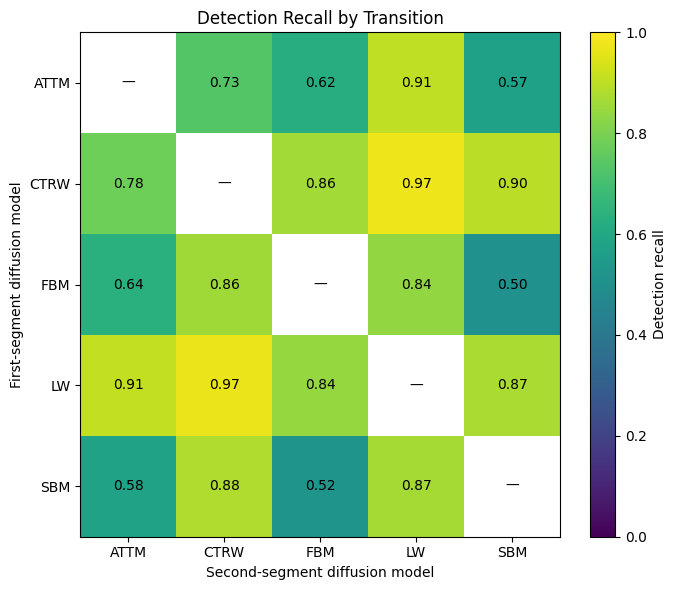

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\localization_rmse_by_transition.png


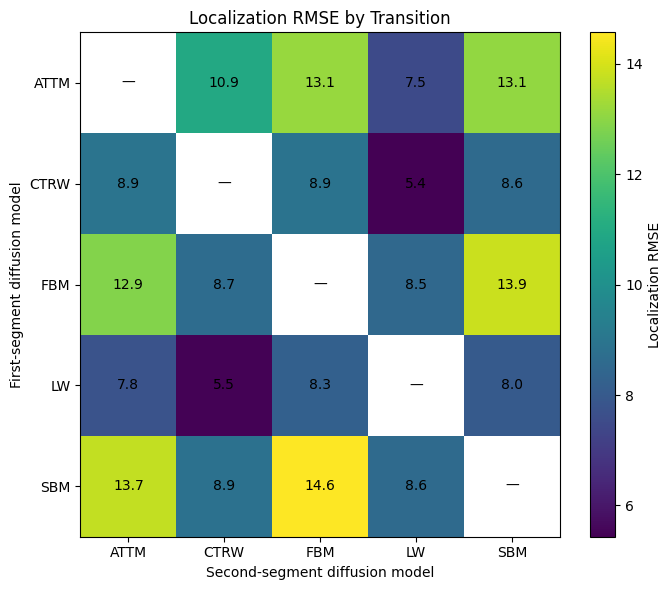

In [14]:

def transition_matrix(column):
    matrix = pd.DataFrame(np.nan, index=MODEL_NAMES, columns=MODEL_NAMES, dtype=float)
    for _, row in transition_metrics.iterrows():
        matrix.loc[row["model1"], row["model2"]] = row[column]
    return matrix


def plot_transition_matrix(matrix, title, colorbar_label, filename, value_format="{:.2f}", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix.values, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(MODEL_NAMES)))
    ax.set_yticks(np.arange(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_yticklabels(MODEL_NAMES)
    ax.set_xlabel("Second-segment diffusion model")
    ax.set_ylabel("First-segment diffusion model")
    ax.set_title(title)

    for i in range(len(MODEL_NAMES)):
        for j in range(len(MODEL_NAMES)):
            value = matrix.iloc[i, j]
            text = "—" if np.isnan(value) else value_format.format(value)
            ax.text(j, i, text, ha="center", va="center")

    plt.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()


recall_matrix = transition_matrix("detection_recall")
fnr_matrix = transition_matrix("false_negative_rate")
rmse_matrix = transition_matrix("rmse_true_positive")

plot_transition_matrix(
    recall_matrix,
    "Detection Recall by Transition",
    "Detection recall",
    "detection_recall_by_transition.png",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)

plot_transition_matrix(
    rmse_matrix,
    "Localization RMSE by Transition",
    "Localization RMSE",
    "localization_rmse_by_transition.png",
    value_format="{:.1f}",
)


## 13. Identificación de transiciones de distinta dificultad

Se calcula una medida de dificultad que combina la tasa de falsos negativos y el error de localización. Las transiciones con menor sensibilidad o mayor error temporal se consideran más difíciles.

Esta ordenación facilita la selección de casos representativos y la comparación posterior con otras arquitecturas.


In [15]:

def minmax(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())


difficulty = transition_metrics.copy()
difficulty["rmse_for_score"] = difficulty["rmse_true_positive"].fillna(difficulty["rmse_all"])
difficulty["difficulty_score"] = minmax(difficulty["false_negative_rate"]) + minmax(difficulty["rmse_for_score"])

easy = difficulty.sort_values("difficulty_score").head(5).copy()
difficult = difficulty.sort_values("difficulty_score", ascending=False).head(5).copy()

easy["category"] = "Easy"
difficult["category"] = "Difficult"

easy_difficult = pd.concat([easy, difficult], ignore_index=True)
easy_difficult["interpretation"] = np.where(
    easy_difficult["category"] == "Easy",
    "High detection recall and low localization error.",
    "Low detection recall and/or high localization error.",
)

easy_difficult = easy_difficult[
    [
        "category",
        "transition",
        "detection_recall",
        "false_negative_rate",
        "mae_all",
        "rmse_all",
        "mae_true_positive",
        "rmse_true_positive",
        "interpretation",
    ]
]

easy_difficult.to_csv(OUTPUT_DIR / "easy_difficult_transitions.csv", index=False)
easy_difficult


,category,transition,detection_recall,false_negative_rate,mae_all,rmse_all,mae_true_positive,rmse_true_positive,interpretation
0,Easy,CTRW → LW,0.9728,0.0272,2.900056,5.930214,2.636034,5.432540,High detection recall and low localization error.
1,Easy,LW → CTRW,0.9714,0.0286,3.011273,6.045670,2.748979,5.500955,High detection recall and low localization error.
2,Easy,ATTM → LW,0.9056,0.0944,4.939293,8.693556,4.069117,7.474002,High detection recall and low localization error.
3,Easy,LW → ATTM,0.9096,0.0904,5.278600,9.070479,4.386916,7.774135,High detection recall and low localization error.
4,Easy,LW → SBM,0.8712,0.1288,5.800409,9.691602,4.532389,8.004930,High detection recall and low localization error.
5,Difficult,SBM → FBM,0.5182,0.4818,12.606802,15.736448,11.227489,14.572122,Low detection recall and/or high localization ...
6,Difficult,FBM → SBM,0.5046,0.4954,12.253055,15.408933,10.461517,13.851065,Low detection recall and/or high localization ...
7,Difficult,SBM → ATTM,0.5774,0.4226,11.279525,14.774602,9.850928,13.716052,Low detection recall and/or high localization ...
8,Difficult,ATTM → SBM,0.5736,0.4264,10.997656,14.686954,8.976659,13.078195,Low detection recall and/or high localization ...
9,Difficult,ATTM → FBM,0.6222,0.3778,11.242440,14.850614,9.278890,13.144127,Low detection recall and/or high localization ...


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\transition_level_detection_localization_difficulty.png


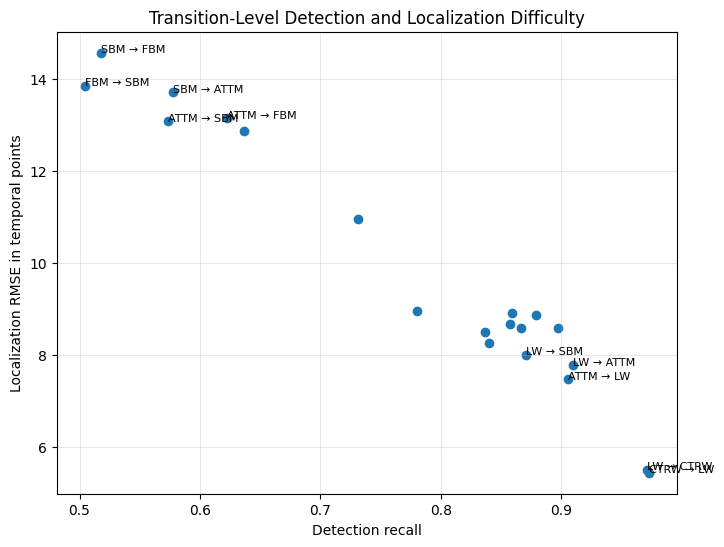

In [16]:

plot_data = difficulty.copy()
plt.figure(figsize=(8, 6))
plt.scatter(plot_data["detection_recall"], plot_data["rmse_for_score"])

for _, row in pd.concat([easy, difficult]).iterrows():
    plt.text(row["detection_recall"], row["rmse_for_score"], row["transition"], fontsize=8)

plt.xlabel("Detection recall")
plt.ylabel("Localization RMSE in temporal points")
plt.title("Transition-Level Detection and Localization Difficulty")
plt.grid(alpha=0.3)
save_current_figure("transition_level_detection_localization_difficulty.png")
plt.show()


## 14. Ejemplos representativos de trayectorias

Se visualizan trayectorias asociadas a transiciones de distinta dificultad. La posición real del punto de cambio y la estimación derivada de `cp_dist` permiten comparar de forma cualitativa la referencia temporal con la predicción del modelo.

Estos ejemplos conectan el comportamiento numérico del modelo con patrones concretos observados en `dx(t)`.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\representative_trajectories_true_predicted_changepoints.png


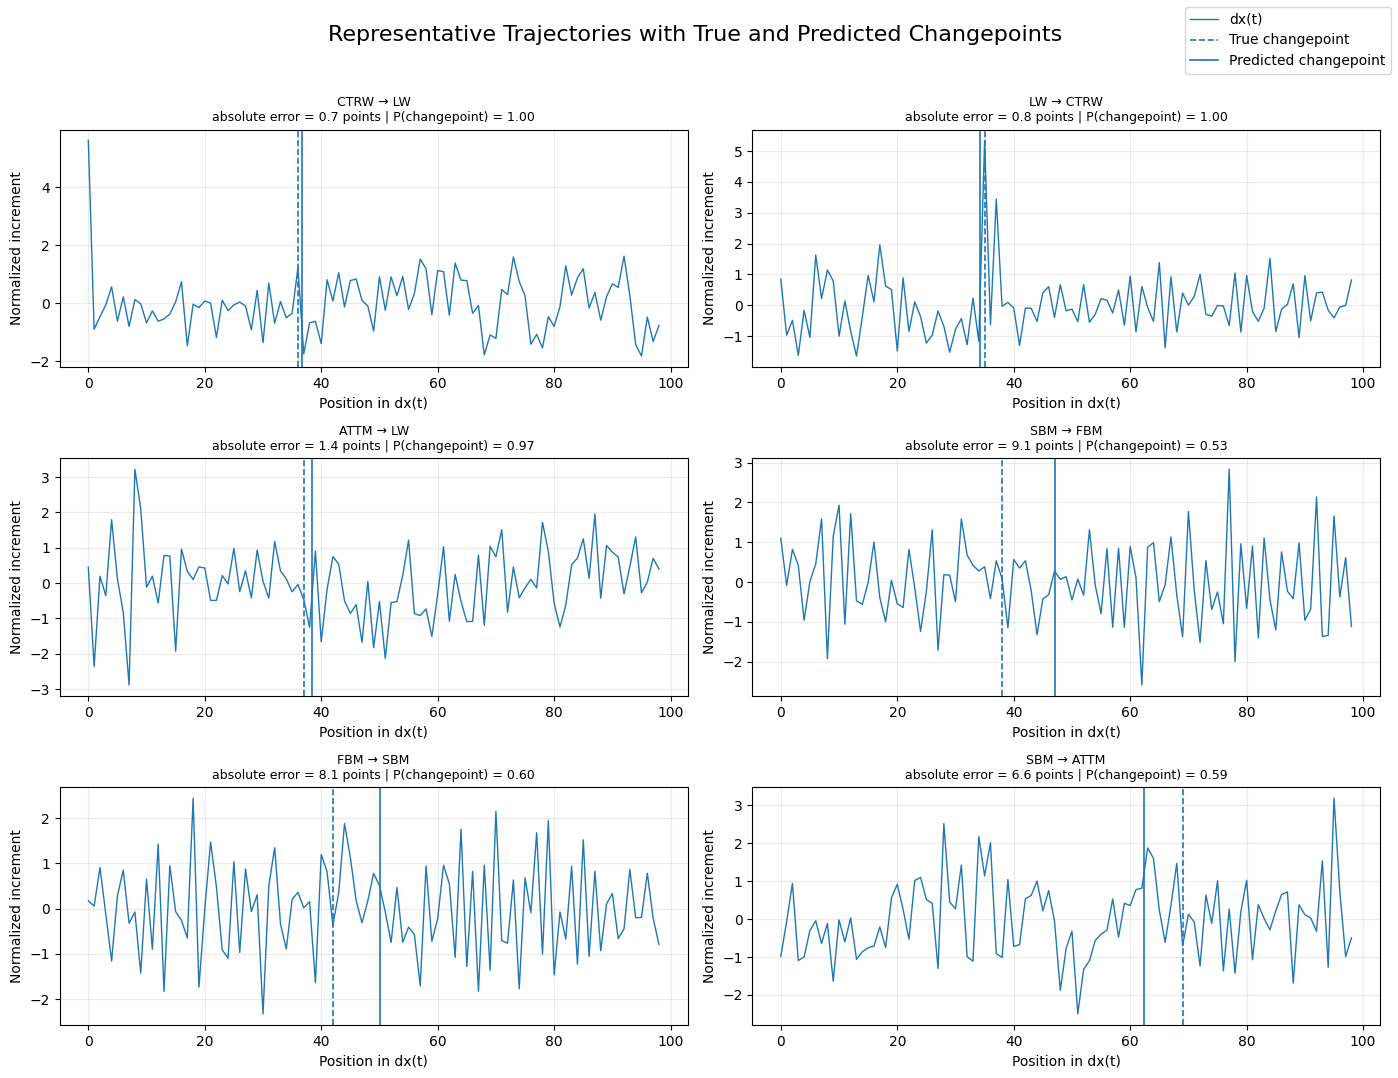

In [17]:

selected_transitions = easy["transition"].tolist()[:3] + difficult["transition"].tolist()[:3]
selected_indices = []

for transition in selected_transitions:
    group = results_frame[(results_frame["has_changepoint"] == 1) & (results_frame["transition"] == transition)].copy()
    tp_group = group[group["has_cp_pred"] == 1].copy()
    if len(tp_group):
        group = tp_group
    if len(group):
        median_error = group["abs_error"].median()
        selected_indices.append((group["abs_error"] - median_error).abs().idxmin())

n_cols = 2
n_rows = int(np.ceil(len(selected_indices) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)
axes = axes.ravel()

for ax, idx in zip(axes, selected_indices):
    row = results_frame.loc[idx]
    ax.plot(x_test[idx, :, 0], linewidth=1.0, label="dx(t)")
    ax.axvline(row["cp_dx"], linestyle="--", linewidth=1.2, label="True changepoint")
    ax.axvline(row["pred_cp"] - 1.0, linestyle="-", linewidth=1.2, label="Predicted changepoint")
    ax.set_title(
        f"{row['transition']}\nabsolute error = {row['abs_error']:.1f} points | P(changepoint) = {row['has_cp_prob']:.2f}",
        fontsize=9,
    )
    ax.set_xlabel("Position in dx(t)")
    ax.set_ylabel("Normalized increment")
    ax.grid(alpha=0.25)

for j in range(len(selected_indices), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Representative Trajectories with True and Predicted Changepoints", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_current_figure("representative_trajectories_true_predicted_changepoints.png")
plt.show()


## 15. Evaluación complementaria del modelo

Las siguientes celdas amplían el análisis del mejor modelo guardado mediante visualizaciones adicionales. Se estudian falsos negativos, falsos positivos, errores de localización por transición y dependencia del rendimiento respecto a la posición temporal real del punto de cambio.

Estas salidas no modifican el entrenamiento ni la arquitectura; su finalidad es interpretar con mayor detalle el comportamiento del ConvTransformer frente a trayectorias con y sin punto de cambio.

In [18]:

def build_transition_matrix(metric_name):
    matrix = pd.DataFrame(np.nan, index=MODEL_NAMES, columns=MODEL_NAMES, dtype=float)
    for _, row in transition_metrics.iterrows():
        matrix.loc[row["model1"], row["model2"]] = row[metric_name]
    return matrix


def save_matrix_csv(matrix, filename):
    path = OUTPUT_DIR / filename
    matrix.to_csv(path)
    return path


def plot_matrix(matrix, title, colorbar_label, filename, value_format="{:.2f}", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix.values, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(MODEL_NAMES)))
    ax.set_yticks(np.arange(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_yticklabels(MODEL_NAMES)
    ax.set_xlabel("Second-segment diffusion model")
    ax.set_ylabel("First-segment diffusion model")
    ax.set_title(title)

    for i in range(len(MODEL_NAMES)):
        for j in range(len(MODEL_NAMES)):
            value = matrix.iloc[i, j]
            text = "—" if np.isnan(value) else value_format.format(value)
            ax.text(j, i, text, ha="center", va="center")

    plt.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()


### 15.1 Tasa de falsos negativos por transición

Esta matriz muestra, para cada transición real, la proporción de trayectorias con punto de cambio clasificadas como trayectorias sin punto de cambio. Los valores altos indican transiciones cuya detección resulta especialmente difícil para el modelo.

El análisis permite localizar patrones de error que no siempre son visibles en las métricas globales.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\false_negative_rate_by_transition.png


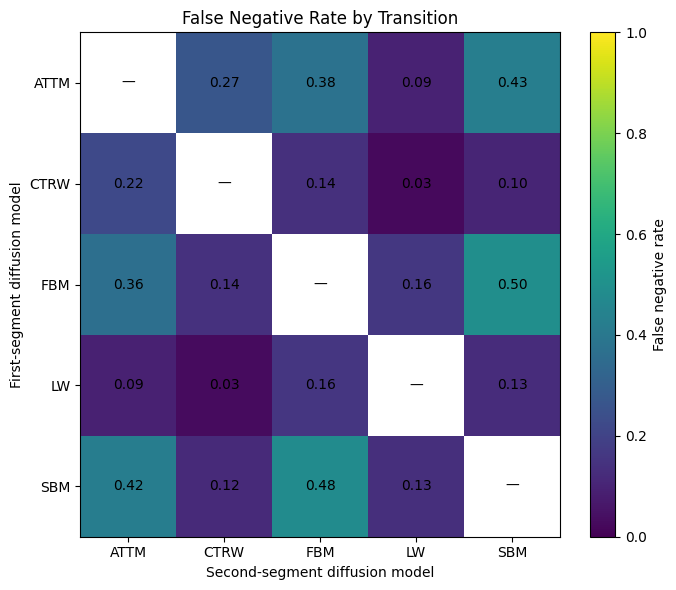

,ATTM,CTRW,FBM,LW,SBM
ATTM,NaN,0.2684,0.3778,0.0944,0.4264
CTRW,0.2198,NaN,0.1404,0.0272,0.1022
FBM,0.3636,0.1428,NaN,0.1632,0.4954
LW,0.0904,0.0286,0.1600,NaN,0.1288
SBM,0.4226,0.1210,0.4818,0.1334,NaN


In [19]:

false_negative_matrix = build_transition_matrix("false_negative_rate")
save_matrix_csv(false_negative_matrix, "false_negative_rate_by_transition.csv")

plot_matrix(
    false_negative_matrix,
    "False Negative Rate by Transition",
    "False negative rate",
    "false_negative_rate_by_transition.png",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)

false_negative_matrix


### 15.2 Tasa de falsos positivos en trayectorias sin punto de cambio

Esta tabla y su figura identifican qué modelos homogéneos generan con mayor frecuencia predicciones incorrectas de punto de cambio.

El resultado permite evaluar si determinadas dinámicas de difusión anómala producen fluctuaciones que el ConvTransformer interpreta como indicios de transición, aun cuando la trayectoria no contiene un punto de cambio real.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\false_positive_rate_by_no_changepoint_model.png


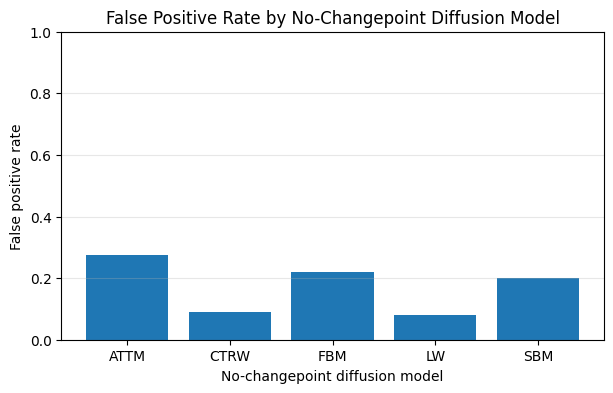

,diffusion_model,total_no_changepoint,false_positives,false_positive_rate
0,ATTM,20000,5501,0.27505
1,CTRW,20000,1829,0.09145
2,FBM,20000,4399,0.21995
3,LW,20000,1586,0.07930
4,SBM,20000,4009,0.20045


In [20]:

no_changepoint_results = results_frame[results_frame["has_changepoint"] == 0].copy()

false_positive_by_model = (
    no_changepoint_results
    .groupby("model1")
    .agg(
        total_no_changepoint=("has_cp_pred", "size"),
        false_positives=("has_cp_pred", "sum"),
        false_positive_rate=("has_cp_pred", "mean"),
    )
    .reindex(MODEL_NAMES)
    .reset_index()
    .rename(columns={"model1": "diffusion_model"})
)

false_positive_by_model.to_csv(OUTPUT_DIR / "false_positive_rate_by_no_changepoint_model.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(false_positive_by_model["diffusion_model"], false_positive_by_model["false_positive_rate"])
plt.ylim(0, 1)
plt.xlabel("No-changepoint diffusion model")
plt.ylabel("False positive rate")
plt.title("False Positive Rate by No-Changepoint Diffusion Model")
plt.grid(axis="y", alpha=0.3)
save_current_figure("false_positive_rate_by_no_changepoint_model.png")
plt.show()

false_positive_by_model


### 15.3 Errores MAE y RMSE de localización por transición

Se comparan el error absoluto medio (`MAE`) y la raíz del error cuadrático medio (`RMSE`) para cada transición con punto de cambio. El `MAE` describe el error típico, mientras que el `RMSE` permite detectar la presencia de errores temporales de gran magnitud.

Esta comparación aporta una lectura más completa de la localización temporal que una sola métrica agregada.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\localization_mae_by_transition.png


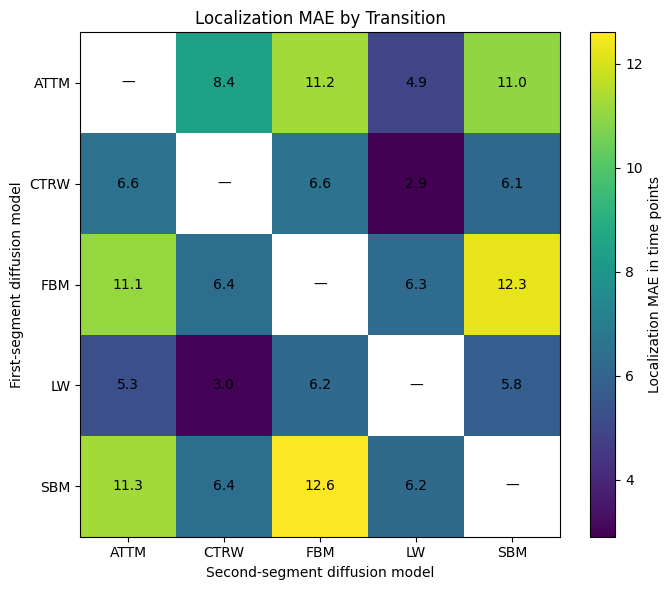

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\localization_rmse_by_transition.png


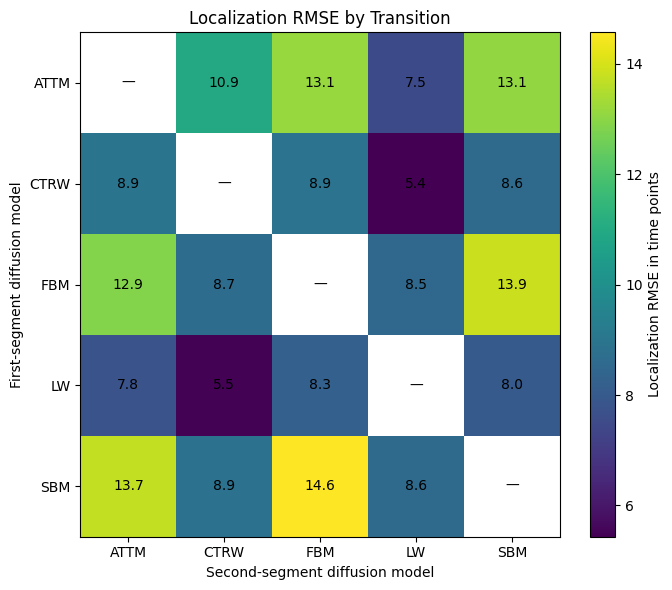

,ATTM,CTRW,FBM,LW,SBM
ATTM,NaN,8.441342,11.242440,4.939293,10.997656
CTRW,6.577915,NaN,6.610991,2.900056,6.127583
FBM,11.082120,6.417902,NaN,6.289558,12.253055
LW,5.278600,3.011273,6.229662,NaN,5.800409
SBM,11.279525,6.413808,12.606802,6.239388,NaN


In [21]:

mae_transition_matrix = build_transition_matrix("mae_all")
rmse_transition_matrix = build_transition_matrix("rmse_true_positive")

save_matrix_csv(mae_transition_matrix, "localization_mae_by_transition.csv")
save_matrix_csv(rmse_transition_matrix, "localization_rmse_by_transition.csv")

plot_matrix(
    mae_transition_matrix,
    "Localization MAE by Transition",
    "Localization MAE in time points",
    "localization_mae_by_transition.png",
    value_format="{:.1f}",
)

plot_matrix(
    rmse_transition_matrix,
    "Localization RMSE by Transition",
    "Localization RMSE in time points",
    "localization_rmse_by_transition.png",
    value_format="{:.1f}",
)

mae_transition_matrix


### 15.4 Ordenación de transiciones según dificultad

La clasificación combina errores de detección y de localización para ordenar las transiciones de menor a mayor dificultad. Las transiciones con alta sensibilidad y bajo error temporal ocupan las posiciones más favorables.

Esta ordenación resulta útil para interpretar el comportamiento del modelo y seleccionar ejemplos cualitativos representativos.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\transition_difficulty_ranking.png


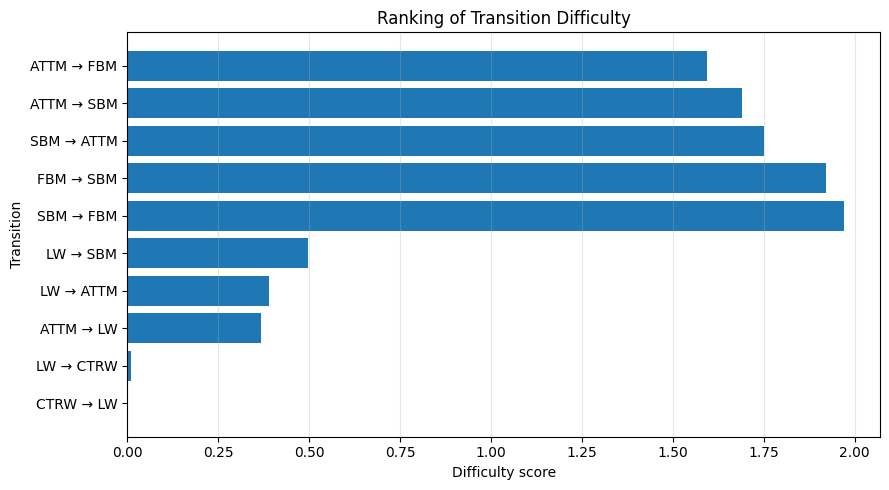

Top 5 easiest transitions


,rank,transition,detection_recall,false_negative_rate,localization_mae,localization_rmse,difficulty_score,interpretation
0,1,CTRW → LW,0.9728,0.0272,2.636034,5.432540,0.000000,Easy transition: high detection recall and low...
1,2,LW → CTRW,0.9714,0.0286,2.748979,5.500955,0.010476,Easy transition: high detection recall and low...
2,3,ATTM → LW,0.9056,0.0944,4.069117,7.474002,0.366893,Easy transition: high detection recall and low...
3,4,LW → ATTM,0.9096,0.0904,4.386916,7.774135,0.391189,Easy transition: high detection recall and low...
4,5,LW → SBM,0.8712,0.1288,4.532389,8.004930,0.498457,Easy transition: high detection recall and low...


Top 5 most difficult transitions


,rank,transition,detection_recall,false_negative_rate,localization_mae,localization_rmse,difficulty_score,interpretation
19,20,SBM → FBM,0.5182,0.4818,11.227489,14.572122,1.970953,Difficult transition: low detection recall and...
18,19,FBM → SBM,0.5046,0.4954,10.461517,13.851065,1.921106,Difficult transition: low detection recall and...
17,18,SBM → ATTM,0.5774,0.4226,9.850928,13.716052,1.750845,Difficult transition: low detection recall and...
16,17,ATTM → SBM,0.5736,0.4264,8.976659,13.078195,1.689170,Difficult transition: low detection recall and...
15,16,ATTM → FBM,0.6222,0.3778,9.278890,13.144127,1.592582,Difficult transition: low detection recall and...


In [22]:

transition_ranking = transition_metrics.copy()
transition_ranking["localization_rmse"] = transition_ranking["rmse_true_positive"].fillna(transition_ranking["rmse_all"])
transition_ranking["localization_mae"] = transition_ranking["mae_true_positive"].fillna(transition_ranking["mae_all"])

def normalized_series(values):
    values = values.astype(float)
    if values.max() == values.min():
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - values.min()) / (values.max() - values.min())

transition_ranking["normalized_false_negative_rate"] = normalized_series(transition_ranking["false_negative_rate"])
transition_ranking["normalized_localization_rmse"] = normalized_series(transition_ranking["localization_rmse"])
transition_ranking["difficulty_score"] = (
    transition_ranking["normalized_false_negative_rate"] +
    transition_ranking["normalized_localization_rmse"]
)

ranked_transitions = transition_ranking.sort_values("difficulty_score").reset_index(drop=True)
ranked_transitions["rank"] = np.arange(1, len(ranked_transitions) + 1)
ranked_transitions["interpretation"] = np.where(
    ranked_transitions["rank"] <= 5,
    "Easy transition: high detection recall and low localization error.",
    np.where(
        ranked_transitions["rank"] > len(ranked_transitions) - 5,
        "Difficult transition: low detection recall and/or high localization error.",
        "Intermediate transition."
    )
)

transition_difficulty_ranking = ranked_transitions[
    [
        "rank",
        "transition",
        "detection_recall",
        "false_negative_rate",
        "localization_mae",
        "localization_rmse",
        "difficulty_score",
        "interpretation",
    ]
]

transition_difficulty_ranking.to_csv(OUTPUT_DIR / "transition_difficulty_ranking.csv", index=False)

top_easiest = transition_difficulty_ranking.head(5)
top_difficult = transition_difficulty_ranking.tail(5).sort_values("difficulty_score", ascending=False)

plt.figure(figsize=(9, 5))
plot_table = pd.concat([top_easiest, top_difficult])
plt.barh(plot_table["transition"], plot_table["difficulty_score"])
plt.xlabel("Difficulty score")
plt.ylabel("Transition")
plt.title("Ranking of Transition Difficulty")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_current_figure("transition_difficulty_ranking.png")
plt.show()

print("Top 5 easiest transitions")
display(top_easiest)

print("Top 5 most difficult transitions")
display(top_difficult)



### 15.5 Error de localización según intervalo temporal del punto de cambio

Las trayectorias con punto de cambio se agrupan según la zona temporal en la que aparece la transición real. Esta evaluación permite analizar si el modelo localiza mejor los cambios situados en la zona central o si pierde precisión cerca de los extremos.

La dependencia temporal es relevante porque el contexto disponible antes y después del cambio puede afectar a la estimación.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\performance_by_true_changepoint_interval.png


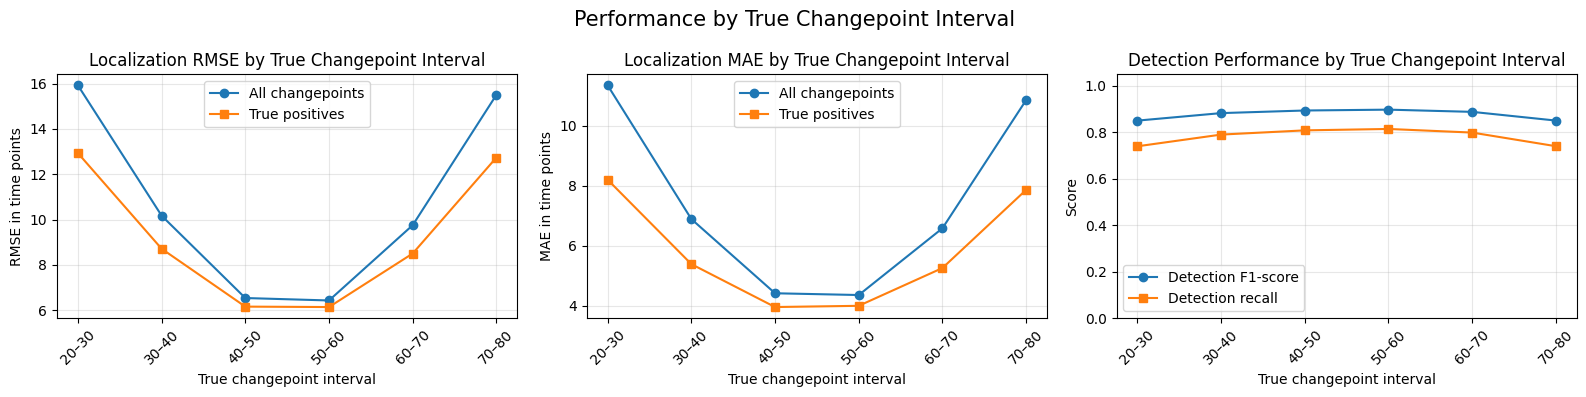

,true_changepoint_interval,number_of_examples,detection_recall,detection_f1_score,localization_mae,localization_rmse,localization_mae_true_positive,localization_rmse_true_positive
0,20–30,16516,0.740131,0.850661,11.356070,15.917408,8.202806,12.928434
1,30–40,16224,0.790496,0.882991,6.888777,10.168602,5.383847,8.709575
2,40–50,16319,0.808689,0.894227,4.410298,6.535929,3.950071,6.156827
3,50–60,16436,0.814736,0.897911,4.351806,6.428106,3.991248,6.138154
4,60–70,16482,0.799175,0.888379,6.581913,9.749243,5.253705,8.499640
5,70–80,16327,0.740491,0.850899,10.864304,15.497772,7.864935,12.734310


In [23]:

changepoint_results = results_frame[results_frame["has_changepoint"] == 1].copy()

min_cp = int(np.floor(changepoint_results["cp"].min() / 10) * 10)
max_cp = int(np.ceil(changepoint_results["cp"].max() / 10) * 10)
bins = np.arange(min_cp, max_cp + 10, 10)

if len(bins) < 3:
    bins = np.linspace(changepoint_results["cp"].min(), changepoint_results["cp"].max() + 1, 4)

labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
changepoint_results["cp_interval"] = pd.cut(
    changepoint_results["cp"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

interval_rows = []

for interval, group in changepoint_results.groupby("cp_interval", observed=False):
    if len(group) == 0:
        continue

    tp_group = group[group["has_cp_pred"] == 1]
    y_true_interval = np.ones(len(group), dtype=int)
    y_pred_interval = group["has_cp_pred"].to_numpy(dtype=int)

    interval_rows.append({
        "true_changepoint_interval": str(interval),
        "number_of_examples": int(len(group)),
        "detection_recall": float(group["has_cp_pred"].mean()),
        "detection_f1_score": float(f1_score(y_true_interval, y_pred_interval, zero_division=0)),
        "localization_mae": float(group["abs_error"].mean()),
        "localization_rmse": float(np.sqrt(group["squared_error"].mean())),
        "localization_mae_true_positive": float(tp_group["abs_error"].mean()) if len(tp_group) else np.nan,
        "localization_rmse_true_positive": float(np.sqrt(tp_group["squared_error"].mean())) if len(tp_group) else np.nan,
    })

interval_performance = pd.DataFrame(interval_rows)
interval_performance.to_csv(OUTPUT_DIR / "changepoint_interval_performance.csv", index=False)

x_positions = np.arange(len(interval_performance))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(x_positions, interval_performance["localization_rmse"], marker="o", label="All changepoints")
axes[0].plot(x_positions, interval_performance["localization_rmse_true_positive"], marker="s", label="True positives")
axes[0].set_title("Localization RMSE by True Changepoint Interval")
axes[0].set_xlabel("True changepoint interval")
axes[0].set_ylabel("RMSE in time points")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_positions, interval_performance["localization_mae"], marker="o", label="All changepoints")
axes[1].plot(x_positions, interval_performance["localization_mae_true_positive"], marker="s", label="True positives")
axes[1].set_title("Localization MAE by True Changepoint Interval")
axes[1].set_xlabel("True changepoint interval")
axes[1].set_ylabel("MAE in time points")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(x_positions, interval_performance["detection_f1_score"], marker="o", label="Detection F1-score")
axes[2].plot(x_positions, interval_performance["detection_recall"], marker="s", label="Detection recall")
axes[2].set_title("Detection Performance by True Changepoint Interval")
axes[2].set_xlabel("True changepoint interval")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Performance by True Changepoint Interval", fontsize=15)
plt.tight_layout()
save_current_figure("performance_by_true_changepoint_interval.png")
plt.show()

interval_performance


### 15.6 Relación entre MAE y RMSE por transición

La figura compara `MAE` y `RMSE` por transición. Cuando el `RMSE` es considerablemente mayor que el `MAE`, la transición puede contener errores aislados de gran magnitud.

Esta lectura ayuda a distinguir entre errores distribuidos de forma regular y fallos puntuales con fuerte impacto en la métrica cuadrática.


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\mae_rmse_relationship_by_transition.png


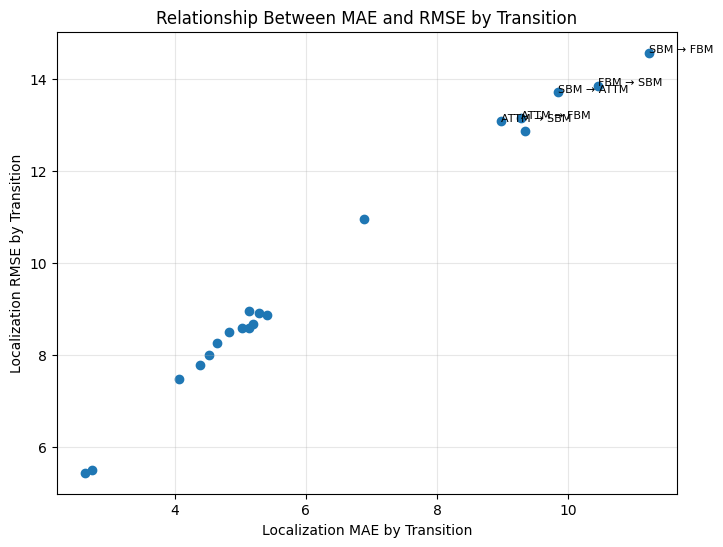

In [24]:

relationship_data = transition_metrics.copy()
relationship_data["relationship_mae"] = relationship_data["mae_true_positive"].fillna(relationship_data["mae_all"])
relationship_data["relationship_rmse"] = relationship_data["rmse_true_positive"].fillna(relationship_data["rmse_all"])

plt.figure(figsize=(8, 6))
plt.scatter(relationship_data["relationship_mae"], relationship_data["relationship_rmse"])

for _, row in top_difficult.iterrows():
    transition_name = row["transition"]
    point = relationship_data[relationship_data["transition"] == transition_name].iloc[0]
    plt.text(point["relationship_mae"], point["relationship_rmse"], transition_name, fontsize=8)

plt.xlabel("Localization MAE by Transition")
plt.ylabel("Localization RMSE by Transition")
plt.title("Relationship Between MAE and RMSE by Transition")
plt.grid(alpha=0.3)
save_current_figure("mae_rmse_relationship_by_transition.png")
plt.show()


### 15.7 Rendimiento en función de la posición temporal del punto de cambio

Esta visualización resume cómo cambia el rendimiento según la posición real del punto de cambio dentro de la trayectoria. El objetivo es detectar posibles sesgos temporales en la capacidad de detección o localización.

Un comportamiento estable a lo largo de los intervalos temporales indicaría que el modelo aprovecha de manera equilibrada la información disponible en la secuencia.


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures\changepoint_position_dependent_performance.png


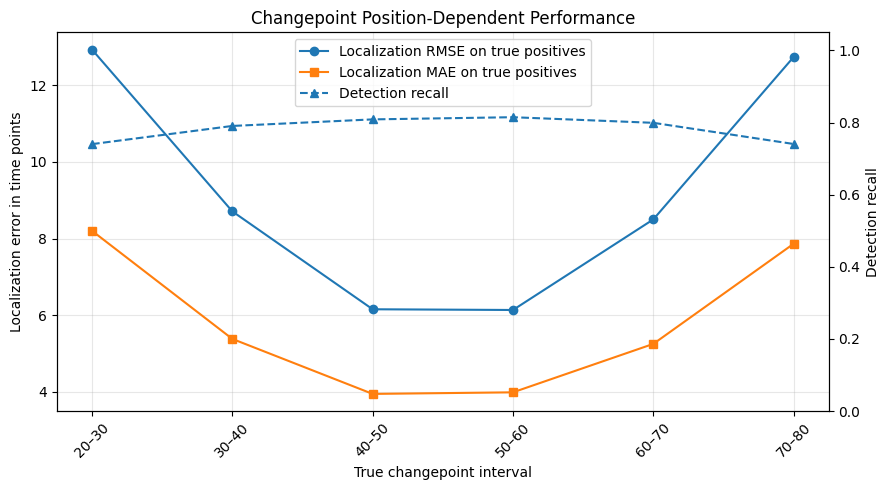

In [25]:

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["localization_rmse_true_positive"],
    marker="o",
    label="Localization RMSE on true positives",
)
ax1.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["localization_mae_true_positive"],
    marker="s",
    label="Localization MAE on true positives",
)
ax1.set_xlabel("True changepoint interval")
ax1.set_ylabel("Localization error in time points")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["detection_recall"],
    marker="^",
    linestyle="--",
    label="Detection recall",
)
ax2.set_ylabel("Detection recall")
ax2.set_ylim(0, 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center")

plt.title("Changepoint Position-Dependent Performance")
plt.tight_layout()
save_current_figure("changepoint_position_dependent_performance.png")
plt.show()


### 15.8 Interpretación intermedia de la evaluación complementaria

La evaluación complementaria separa distintos tipos de error para facilitar la interpretación del ConvTransformer. La tasa de falsos negativos identifica transiciones reales que no se detectan de forma consistente, mientras que la tasa de falsos positivos muestra qué trayectorias homogéneas producen alertas incorrectas.

El análisis de `MAE`, `RMSE` y posición temporal del punto de cambio permite estudiar la localización desde una perspectiva más detallada. Esta sección funciona como lectura intermedia de las visualizaciones anteriores y reserva la síntesis cuantitativa del modelo para el resumen final.

## Resumen final

En este cuaderno se evaluó un modelo ConvTransformer para detección binaria y localización temporal en trayectorias con y sin punto de cambio, utilizando como entrada la serie de incrementos `dx(t)`. El umbral seleccionado fue `0.30`.

En el conjunto de test, el modelo alcanzó una `accuracy` de `0.803675`, una `precision` de `0.818374`, un `recall` de `0.780590`, un `F1-score` de `0.799036`, un `FPR` de `0.173240` y un `FNR` de `0.219410`.

Para la localización temporal, considerando todas las trayectorias con punto de cambio, el `MAE` fue `7.536969` y el `RMSE` fue `11.570613`. Entre las trayectorias correctamente detectadas como positivas, el `MAE` fue `5.779737` y el `RMSE` fue `9.621539`.

Estos resultados resumen el comportamiento del ConvTransformer en la detección de puntos de cambio y en la estimación de su posición temporal.

In [26]:

final_summary = {
    "mode": "FAST_RUN" if FAST_RUN else "GLOBAL_RUN",
    "train_samples": int(x_train.shape[0]),
    "validation_samples": int(x_val.shape[0]),
    "test_samples": int(x_test.shape[0]),
    "selected_threshold": selected_threshold,
    "loss_weights": LOSS_WEIGHTS,
    "global_test_summary": global_summary.to_dict(orient="records"),
    "output_dir": str(OUTPUT_DIR),
}

with open(OUTPUT_DIR / "final_summary_convtransformer_detection_localization_dx.json", "w", encoding="utf-8") as file:
    json.dump(final_summary, file, indent=2, ensure_ascii=False)

best_model.save(OUTPUT_DIR / "convtransformer_detection_localization_dx_best_model.keras")

print("Evaluation outputs saved in:", OUTPUT_DIR)
print("Figures saved in:", FIGURES_DIR)


Evaluation outputs saved in: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx
Figures saved in: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convtransformer_softmax_fpr_fine_thresholds_global_detection_localization_dx\figures
